In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
from collections import Counter
import re
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

In [3]:
listings = pd.read_csv("..\\Data\\Airbnb_NY_City_04112024\\listings.csv")
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2595,https://www.airbnb.com/rooms/2595,20241104040953,2024-11-04,city scrape,Skylit Midtown Castle Sanctuary,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,https://a0.muscache.com/pictures/miso/Hosting-...,2845,https://www.airbnb.com/users/show/2845,Jennifer,2008-09-09,"Woodstock, NY",A New Yorker since 2000! My passion is creatin...,within a day,90%,21%,f,https://a0.muscache.com/im/pictures/user/50fc5...,https://a0.muscache.com/im/pictures/user/50fc5...,Midtown,7.0,9.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Midtown,Manhattan,40.75356,-73.98559,Entire rental unit,Entire home/apt,1,1.0,1 bath,0.0,1.0,"[""Fire extinguisher"", ""Smoke alarm"", ""Stove"", ...",$240.00,30,1125,30.0,30.0,1125.0,1125.0,30.0,1125.0,NaN,t,30,60,90,365,2024-11-04,49,0,0,2009-11-21,2022-06-21,4.68,4.73,4.63,4.77,4.80,4.81,4.40,NaN,f,3,3,0,0,0.27
1,6848,https://www.airbnb.com/rooms/6848,20241104040953,2024-11-04,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,https://www.airbnb.com/users/show/15991,Allen & Irina,2009-05-06,"New York, NY",We love to travel. When we travel we like to s...,within a few hours,100%,100%,t,https://a0.muscache.com/im/users/15991/profile...,https://a0.muscache.com/im/users/15991/profile...,Williamsburg,1.0,1.0,"['email', 'phone']",t,t,NaN,Williamsburg,Brooklyn,40.70935,-73.95342,Entire rental unit,Entire home/apt,3,1.0,1 bath,2.0,1.0,"[""Fire extinguisher"", ""Smoke alarm"", ""Stove"", ...",$83.00,30,120,30.0,30.0,120.0,120.0,30.0,120.0,NaN,t,0,15,15,185,2024-11-04,195,4,1,2009-05-25,2024-10-05,4.58,4.59,4.85,4.85,4.80,4.69,4.58,NaN,f,1,1,0,0,1.04
2,6872,https://www.airbnb.com/rooms/6872,20241104040953,2024-11-04,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,This sweet Harlem sanctuary is a 10-20 minute ...,https://a0.muscache.com/pictures/miso/Hosting-...,16104,https://www.airbnb.com/users/show/16104,Kae,2009-05-07,"New York, NY",A former life in fashion and wellness has left...,a few days or more,30%,33%,f,https://a0.muscache.com/im/pictures/user/d865a...,https://a0.muscache.com/im/pictures/user/d865a...,East Harlem,2.0,2.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,East Harlem,Manhattan,40.80107,-73.94255,Private room in condo,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Heating"", ""Washer"", ""Fire extinguisher"", ""Sm...",$65.00,30,180,30.0,30.0,180.0,180.0,30.0,180.0,NaN,t,23,53,83,83,2024-11-04,1,0,0,2022-06-05,2022-06-05,5.00,5.00,5.00,5.00,5.00,5.00,5.

#### grab and clean amenitites

In [4]:
amenities = listings[['id', 'amenities']]
amenities.head()

,id,amenities
0,2595,"[""Fire extinguisher"", ""Smoke alarm"", ""Stove"", ..."
1,6848,"[""Fire extinguisher"", ""Smoke alarm"", ""Stove"", ..."
2,6872,"[""Heating"", ""Washer"", ""Fire extinguisher"", ""Sm..."
3,6990,"[""Fire extinguisher"", ""Smoke alarm"", ""Stove"", ..."
4,7064,"[""Heating"", ""Washer"", ""Dishes and silverware"",..."


In [5]:
amenities['amenities'] = amenities['amenities'].apply(lambda x: x.strip('[]').replace('"', '').lower())

unique_amenities = set([amenity.strip() for sublist in amenities['amenities'] for amenity in sublist.split(",")])

for amenity in list(unique_amenities):
    amenities[amenity] = amenities['amenities'].apply(
        lambda x: 1 if amenity.strip().lower() in [a.strip().lower() for a in x.split(",")] else 0
    )

amenitites = amenities.drop(columns=[''])

amenities.head()

<positron-console-cell-5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<positron-console-cell-5>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<positron-console-cell-5>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<positron-console-cell-5>:6: SettingWithCopyWarni

,id,amenities,,fast wifi \u2013 399 mbps,-- shampoo,shared gym,fast wifi \u2013 368 mbps,kiehl's amino acid conditioner conditioner,7 google nest home + kmouk sound bars for tv bluetooth sound system,bertazzoni oven,mulitple body soap,blomberg stainless steel gas stove,fast wifi \u2013 718 mbps,vizio sound system,fast wifi \u2013 522 mbps,blackstone,body wash body soap,fast wifi \u2013 244 mbps,full size,tv with standard cable,58 inch tv with amazon prime video,fire pit,dove body wash,paid dryer \u2013 in unit,fast wifi \u2013 635 mbps,redken shampoo,37 inch hdtv with netflix,fridigaire refrigerator,jab\u00f3n l\u00edquido body soap,bath & body works conditioner,variation body soap,fridgidaire gas stove,boom box sound system with aux,kirkland shampoo,bbq grill,natural,lumin shampoo,subzero refrigerator,55 inch tv with premium cable,fast wifi \u2013 489 mbps,tresemme conditioner,hot point single oven,ethanol,freesens,fast wifi \u2013 99 mbps,boat slip,good brand shampoo,kirkland body soap,samsung bluetooth sound system,dove soap body soap,shampoo & conditioner combo conditioner,bob marley bluetooth sound system,the honest co. shampoo,400 inch hdtv,smeg stainless steel stove,spa luxury body soap,free residential garage on premises \u2013 1 space,fast wifi \u2013 124 mbps,premium unisex brand body soap,59 inch hdtv with roku,fast wifi \u2013 696 mbps,32 inch tv,fast wifi \u2013 60 mbps,crosley record player and nakamichi sound system with aux,audio engine hd6+ bluetooth sound system,shared backyard,klipsch and bluetooth ceiling speakers throughout living room/kitchen sound system with aux,high end shampoo and conditioner shampoo,premier 36\ stainless steel stove,dacor single oven,standard body soap,unknown shampoo,hampton stove,dr bronners shampoo,bose sound system with bluetooth and aux,6 inch hdtv with amazon prime video,unique refrigerator,head and shoulders 2 in 1 conditioner,head and shoulders shampoo,generic conditioner,ivory spring body soap,magic chief refrigerator,spirit bath soap body soap,sound bar sound system with bluetooth and aux,fast wifi \u2013 379 mbps,fast wifi \u2013 401 mbps,fast wifi \u2013 212 mbps,2 burner electric stove,fast wifi \u2013 668 mbps,private bbq grill,gas. double oven,face&body bar bergman kelly body soap,fast wifi \u2013 548 mbps,variants of body\u2019s washes body soap,cusimax 1800w ceramic electric hot plate for cooking,fast wifi \u2013 973 mbps,rice maker,kitchenaid stainless steel double oven,natural liquid body wash body soap,fast wifi \u2013 376 mbps,48 inch hdtv with hbo max,bose sound system,best body soap,fast wifi \u2013 697 mbps,malin and goetz shampoo,game console: xbox 360 and xbox one,alba shampoo,moroccan shampoo,housekeeping available 5 hours a day,arganatural coconut oil shampoo,bronxstone goods conditioner,h2o conditioner,shared refrigerator,dove body wash soap body soap,kenmore stove,organic 3 in 1 conditioner,fast wifi \u2013 850 mbps,15 inch hdtv with roku,biosilk hydrating therapy conditioner conditioner,bertazzoni stainless steel electric stove,whirpool stainless steel single oven,yardley london english lavender body soap,45 inch hdtv with amazon prime video,native vegan bodywash body soap,castile body soap,mini fridge refrigerator,h&s conditioner,herbal or similar conditioner,forno stainless steel electric stove,paraben & sulfate-free body soap,shea moisture conditioner,65 inch tv with amazon prime video,dial/dove/palmolive body soap,indoor fireplace: pellet stove,wolf commercial oven - 4 gas range-tops stainless steel oven,all different brand name soaps. body soap,travel kit body soap,arm & hammer and/or dial body soap,natural &/or organic brands shampoo,hotpoint stainless steel stove,fast wifi \u2013 357 mbps,mixed conditioner,fast wifi \u2013 346 mbps,honest company body soap,provided conditioner,swave conditioner,breville convection stainless steel oven,no access without permission,guest must provide own food. no shared consumables refrigerator,there will be a clea

 ### visualize top 100 amenities distribution

In [6]:
amenities['total_amenities'] = amenities['amenities'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)
amenities = amenities.drop(columns=['amenities'])
amenities.head()

<positron-console-cell-6>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


,id,,fast wifi \u2013 399 mbps,-- shampoo,shared gym,fast wifi \u2013 368 mbps,kiehl's amino acid conditioner conditioner,7 google nest home + kmouk sound bars for tv bluetooth sound system,bertazzoni oven,mulitple body soap,blomberg stainless steel gas stove,fast wifi \u2013 718 mbps,vizio sound system,fast wifi \u2013 522 mbps,blackstone,body wash body soap,fast wifi \u2013 244 mbps,full size,tv with standard cable,58 inch tv with amazon prime video,fire pit,dove body wash,paid dryer \u2013 in unit,fast wifi \u2013 635 mbps,redken shampoo,37 inch hdtv with netflix,fridigaire refrigerator,jab\u00f3n l\u00edquido body soap,bath & body works conditioner,variation body soap,fridgidaire gas stove,boom box sound system with aux,kirkland shampoo,bbq grill,natural,lumin shampoo,subzero refrigerator,55 inch tv with premium cable,fast wifi \u2013 489 mbps,tresemme conditioner,hot point single oven,ethanol,freesens,fast wifi \u2013 99 mbps,boat slip,...,32 inch hdtv with disney+,ge appliances stainless steel oven,fast wifi \u2013 313 mbps,hdtv with standard cable,clothing storage: wardrobe and dresser,game console: ps5 and xbox series x,dove men and women conditioner,gas,neutragena rain bath body soap,frigidaire oven,new refrigerator,dial body hair bodywash body soap,standard body soap,edifier sound system with bluetooth and aux,dove/olay or other name brands body soap,wifi \u2013 44 mbps,ge induction stove,bose companion 2 series iii multimedia speakers with aux & pc input sound system with aux,dr. bronner\u2019s pure-castile,treshman conditioner,native conditioner,xxx conditioner,fast wifi \u2013 590 mbps,no disclosed conditioner,fresh shampoo,heads&shoulders shampoo,lg microwave/convection oven stainless steel oven,dove shampoo,miele single oven,fast wifi \u2013 374 mbps,fast wifi \u2013 251 mbps,shared backyard \u2013 not fully fenced,various brand name body bars body soap,fast wifi \u2013 712 mbps,36 inch hdtv with premium cable,open 24 hours,gr 16qf refrigerator,uni body soap,bertazzoni stainless steel stove,belisso,varied i\u2019ll get what guests wants shampoo,56 inch hdtv with apple tv,whirlpool stainless steel induction stove,dovr conditioner,total_amenities
0,2595,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32
1,6848,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,26
2,6872,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,18
3,6990,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19
4,7064,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15


In [7]:
amenities.to_csv("All_amenities_presence_absence.csv")

<Figure size 1000x2000 with 0 Axes>

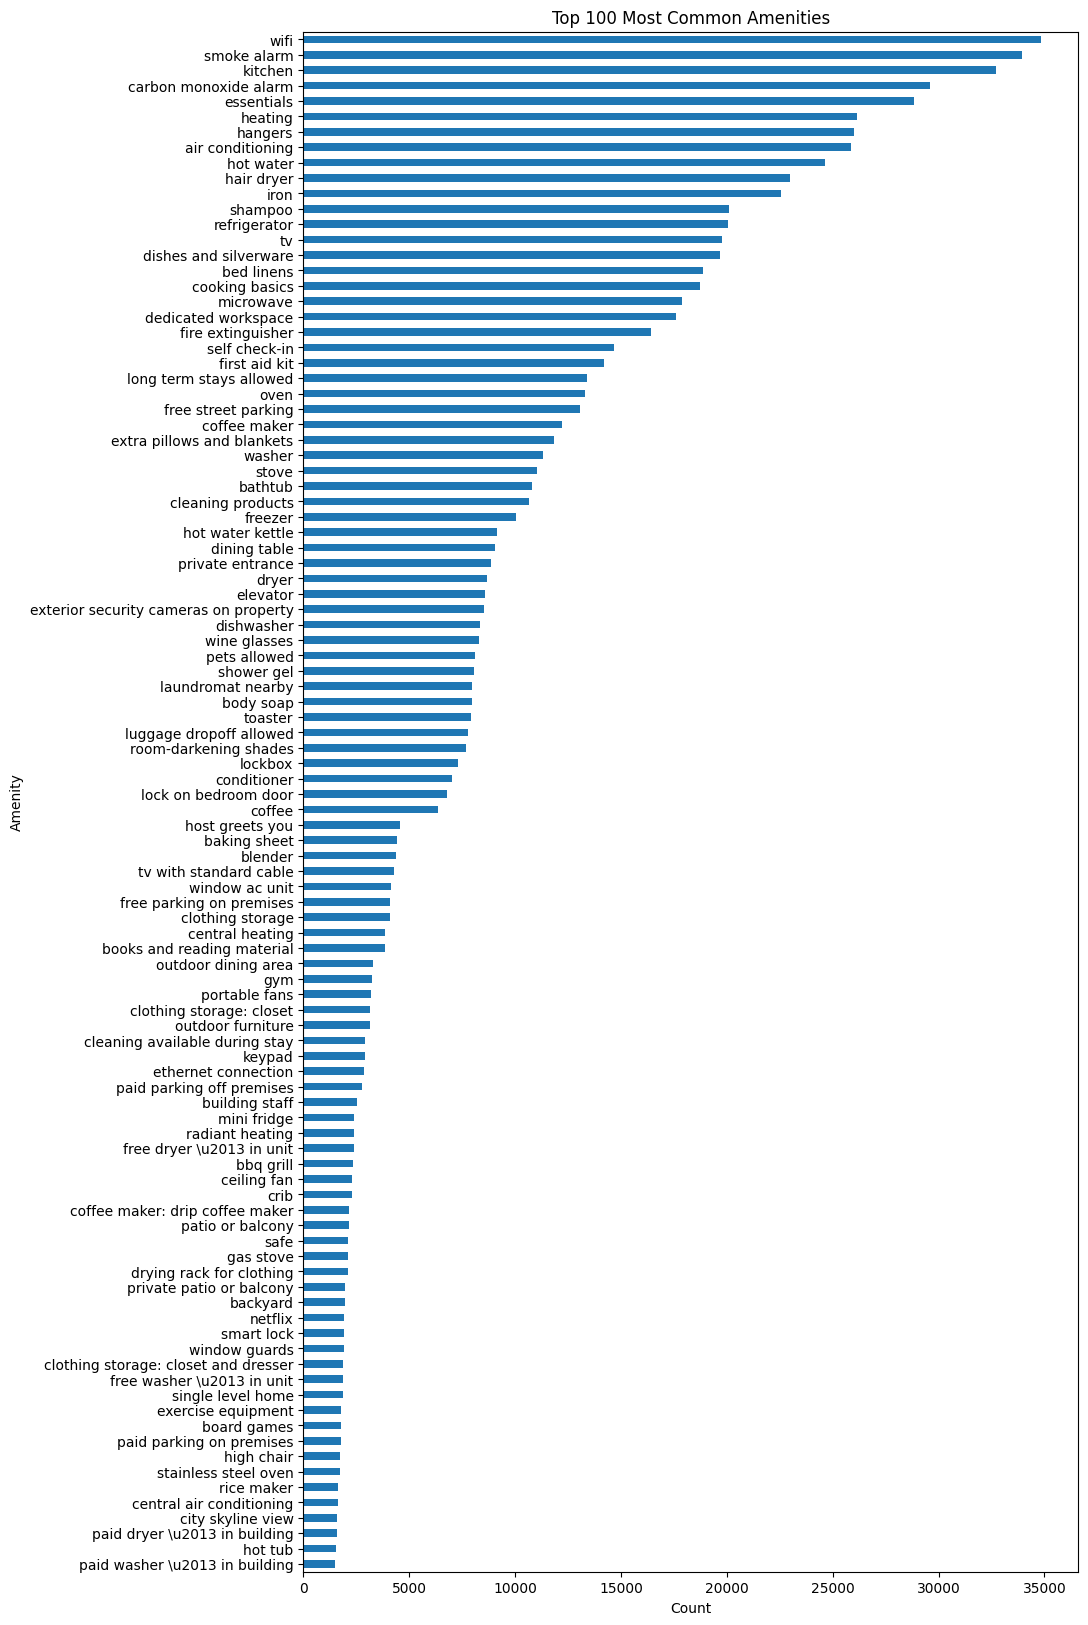

In [10]:
amenities_plot_data = amenities.drop(columns=['id','total_amenities'])
amenity_counts = pd.DataFrame(amenities_plot_data.sum().sort_values(ascending=False)).reset_index()
amenity_counts.columns = ['amenity', 'count']
top_amenities = amenity_counts.head(100)


plt.rcParams["figure.figsize"] = (10, 20) 
plt.figure(figsize=(10,20))
top_amenities.plot(kind='barh', x='amenity', y='count', legend=False)
plt.xlabel('Count')
plt.ylabel('Amenity')
plt.title('Top 100 Most Common Amenities')
plt.gca().invert_yaxis()
plt.show()


In [11]:
wifi_columns = [col for col in amenities.columns if 'wifi' in col.lower()]
wifi_count = amenities[wifi_columns].sum()

print(f"Total count of amenities with 'wifi' in their name: {wifi_count}")

Total count of amenities with 'wifi' in their name: fast wifi \u2013 399 mbps    1
fast wifi \u2013 368 mbps    4
fast wifi \u2013 718 mbps    2
fast wifi \u2013 522 mbps    1
fast wifi \u2013 244 mbps    4
                            ..
wifi \u2013 44 mbps          1
fast wifi \u2013 590 mbps    2
fast wifi \u2013 374 mbps    1
fast wifi \u2013 251 mbps    4
fast wifi \u2013 712 mbps    1
Length: 654, dtype: int64


In [12]:
threshold = len(amenities) * 0.1
filtered_amenities = amenity_counts[amenity_counts['count'] >= threshold]

In [13]:
booking_ratio = pd.read_csv("..\\Data\\Airbnb_NY_City_04112024\\listing_booking_info.csv")[["listing_id","booking_ratio"]]
booking_ratio.head()

,listing_id,booking_ratio
0,2595,0.000000
1,6848,0.493151
2,6872,0.772603
3,6990,0.221918
4,7064,1.000000


### investigate correlations of booking ratio and amenities

In [24]:
# only keep amenity columns that met thhreshold
filtered_amenities_full = amenities
# merged ratio and amenitites
merged_data = pd.merge(filtered_amenities_full, booking_ratio, left_on="id", right_on="listing_id")

# drop non numeric cols
merged_data = merged_data.drop(columns=["id","listing_id"])
merged_data.head()

,,fast wifi \u2013 399 mbps,-- shampoo,shared gym,fast wifi \u2013 368 mbps,kiehl's amino acid conditioner conditioner,7 google nest home + kmouk sound bars for tv bluetooth sound system,bertazzoni oven,mulitple body soap,blomberg stainless steel gas stove,fast wifi \u2013 718 mbps,vizio sound system,fast wifi \u2013 522 mbps,blackstone,body wash body soap,fast wifi \u2013 244 mbps,full size,tv with standard cable,58 inch tv with amazon prime video,fire pit,dove body wash,paid dryer \u2013 in unit,fast wifi \u2013 635 mbps,redken shampoo,37 inch hdtv with netflix,fridigaire refrigerator,jab\u00f3n l\u00edquido body soap,bath & body works conditioner,variation body soap,fridgidaire gas stove,boom box sound system with aux,kirkland shampoo,bbq grill,natural,lumin shampoo,subzero refrigerator,55 inch tv with premium cable,fast wifi \u2013 489 mbps,tresemme conditioner,hot point single oven,ethanol,freesens,fast wifi \u2013 99 mbps,boat slip,good brand shampoo,kirkland body soap,samsung bluetooth sound system,dove soap body soap,shampoo & conditioner combo conditioner,bob marley bluetooth sound system,the honest co. shampoo,400 inch hdtv,smeg stainless steel stove,spa luxury body soap,free residential garage on premises \u2013 1 space,fast wifi \u2013 124 mbps,premium unisex brand body soap,59 inch hdtv with roku,fast wifi \u2013 696 mbps,32 inch tv,fast wifi \u2013 60 mbps,crosley record player and nakamichi sound system with aux,audio engine hd6+ bluetooth sound system,shared backyard,klipsch and bluetooth ceiling speakers throughout living room/kitchen sound system with aux,high end shampoo and conditioner shampoo,premier 36\ stainless steel stove,dacor single oven,standard body soap,unknown shampoo,hampton stove,dr bronners shampoo,bose sound system with bluetooth and aux,6 inch hdtv with amazon prime video,unique refrigerator,head and shoulders 2 in 1 conditioner,head and shoulders shampoo,generic conditioner,ivory spring body soap,magic chief refrigerator,spirit bath soap body soap,sound bar sound system with bluetooth and aux,fast wifi \u2013 379 mbps,fast wifi \u2013 401 mbps,fast wifi \u2013 212 mbps,2 burner electric stove,fast wifi \u2013 668 mbps,private bbq grill,gas. double oven,face&body bar bergman kelly body soap,fast wifi \u2013 548 mbps,variants of body\u2019s washes body soap,cusimax 1800w ceramic electric hot plate for cooking,fast wifi \u2013 973 mbps,rice maker,kitchenaid stainless steel double oven,natural liquid body wash body soap,fast wifi \u2013 376 mbps,48 inch hdtv with hbo max,bose sound system,best body soap,fast wifi \u2013 697 mbps,malin and goetz shampoo,game console: xbox 360 and xbox one,alba shampoo,moroccan shampoo,housekeeping available 5 hours a day,arganatural coconut oil shampoo,bronxstone goods conditioner,h2o conditioner,shared refrigerator,dove body wash soap body soap,kenmore stove,organic 3 in 1 conditioner,fast wifi \u2013 850 mbps,15 inch hdtv with roku,biosilk hydrating therapy conditioner conditioner,bertazzoni stainless steel electric stove,whirpool stainless steel single oven,yardley london english lavender body soap,...,fast wifi \u2013 779 mbps,fast wifi \u2013 622 mbps,nuwave oven,small dorm size fridge refrigerator,ogx conditioner,fast wifi \u2013 203 mbps,fast wifi \u2013 210 mbps,suave essentials,70 inch hdtv with premium cable,kef sound system with bluetooth and aux,audioengine sound system with bluetooth and aux,paid pack \u2019n play/travel crib - always at the listing,ge electric stove,diffeent shampoo,harry's/disney h20+ body soap,fast wifi \u2013 348 mbps,exercise equipment,various organic brands conditioner,49 inch tv with hulu,puracy or jr watkins body soap,koehl\u2019s body soap,luxe body soap,record player,housekeeping available friday - available at extra cost,bbq grill: charcoal,shared pool - available seasonally,camille rose conditioner,booster seat high chair - available upon request,handmade organic body soap for guests body soap,and xbox one,fast wifi \u20

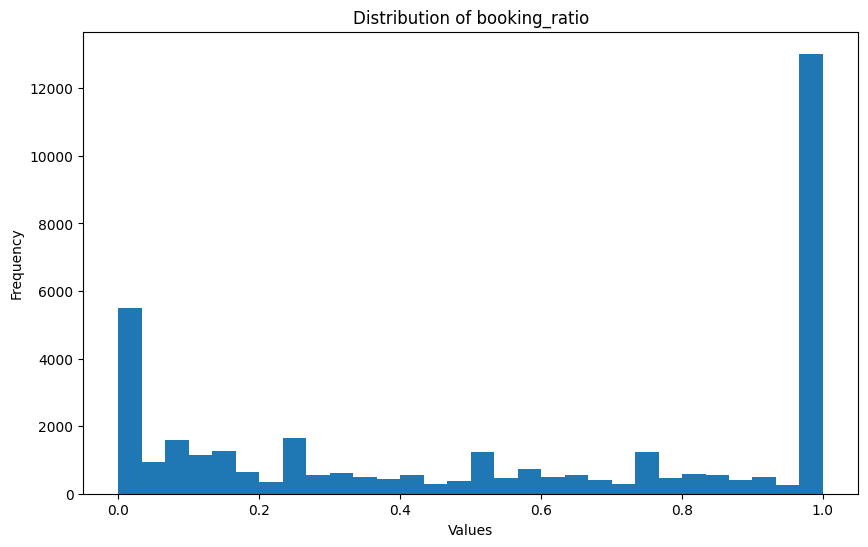

In [25]:
merged_data['booking_ratio'].plot(kind='hist', bins=30, figsize=(10, 6))
plt.title('Distribution of booking_ratio')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

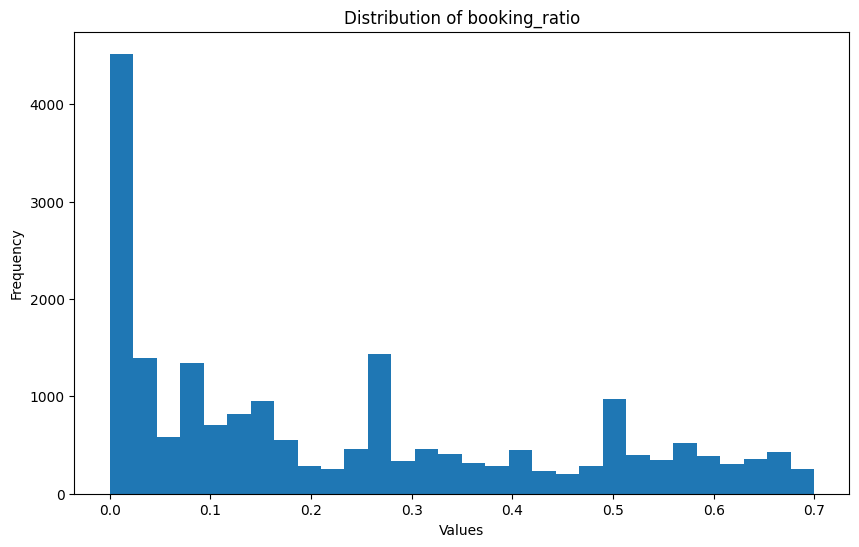

In [26]:
# filter out anything over 70% based on inside airbnb (high booking ratios can be unavailable listings)

filtered_ratio_data = merged_data[merged_data['booking_ratio'] <= 0.70]

filtered_ratio_data['booking_ratio'].plot(kind='hist', bins=30, figsize=(10, 6))
plt.title('Distribution of booking_ratio')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

In [28]:
filtered_ratio_data.head()

,,fast wifi \u2013 399 mbps,-- shampoo,shared gym,fast wifi \u2013 368 mbps,kiehl's amino acid conditioner conditioner,7 google nest home + kmouk sound bars for tv bluetooth sound system,bertazzoni oven,mulitple body soap,blomberg stainless steel gas stove,fast wifi \u2013 718 mbps,vizio sound system,fast wifi \u2013 522 mbps,blackstone,body wash body soap,fast wifi \u2013 244 mbps,full size,tv with standard cable,58 inch tv with amazon prime video,fire pit,dove body wash,paid dryer \u2013 in unit,fast wifi \u2013 635 mbps,redken shampoo,37 inch hdtv with netflix,fridigaire refrigerator,jab\u00f3n l\u00edquido body soap,bath & body works conditioner,variation body soap,fridgidaire gas stove,boom box sound system with aux,kirkland shampoo,bbq grill,natural,lumin shampoo,subzero refrigerator,55 inch tv with premium cable,fast wifi \u2013 489 mbps,tresemme conditioner,hot point single oven,ethanol,freesens,fast wifi \u2013 99 mbps,boat slip,good brand shampoo,kirkland body soap,samsung bluetooth sound system,dove soap body soap,shampoo & conditioner combo conditioner,bob marley bluetooth sound system,the honest co. shampoo,400 inch hdtv,smeg stainless steel stove,spa luxury body soap,free residential garage on premises \u2013 1 space,fast wifi \u2013 124 mbps,premium unisex brand body soap,59 inch hdtv with roku,fast wifi \u2013 696 mbps,32 inch tv,fast wifi \u2013 60 mbps,crosley record player and nakamichi sound system with aux,audio engine hd6+ bluetooth sound system,shared backyard,klipsch and bluetooth ceiling speakers throughout living room/kitchen sound system with aux,high end shampoo and conditioner shampoo,premier 36\ stainless steel stove,dacor single oven,standard body soap,unknown shampoo,hampton stove,dr bronners shampoo,bose sound system with bluetooth and aux,6 inch hdtv with amazon prime video,unique refrigerator,head and shoulders 2 in 1 conditioner,head and shoulders shampoo,generic conditioner,ivory spring body soap,magic chief refrigerator,spirit bath soap body soap,sound bar sound system with bluetooth and aux,fast wifi \u2013 379 mbps,fast wifi \u2013 401 mbps,fast wifi \u2013 212 mbps,2 burner electric stove,fast wifi \u2013 668 mbps,private bbq grill,gas. double oven,face&body bar bergman kelly body soap,fast wifi \u2013 548 mbps,variants of body\u2019s washes body soap,cusimax 1800w ceramic electric hot plate for cooking,fast wifi \u2013 973 mbps,rice maker,kitchenaid stainless steel double oven,natural liquid body wash body soap,fast wifi \u2013 376 mbps,48 inch hdtv with hbo max,bose sound system,best body soap,fast wifi \u2013 697 mbps,malin and goetz shampoo,game console: xbox 360 and xbox one,alba shampoo,moroccan shampoo,housekeeping available 5 hours a day,arganatural coconut oil shampoo,bronxstone goods conditioner,h2o conditioner,shared refrigerator,dove body wash soap body soap,kenmore stove,organic 3 in 1 conditioner,fast wifi \u2013 850 mbps,15 inch hdtv with roku,biosilk hydrating therapy conditioner conditioner,bertazzoni stainless steel electric stove,whirpool stainless steel single oven,yardley london english lavender body soap,...,fast wifi \u2013 779 mbps,fast wifi \u2013 622 mbps,nuwave oven,small dorm size fridge refrigerator,ogx conditioner,fast wifi \u2013 203 mbps,fast wifi \u2013 210 mbps,suave essentials,70 inch hdtv with premium cable,kef sound system with bluetooth and aux,audioengine sound system with bluetooth and aux,paid pack \u2019n play/travel crib - always at the listing,ge electric stove,diffeent shampoo,harry's/disney h20+ body soap,fast wifi \u2013 348 mbps,exercise equipment,various organic brands conditioner,49 inch tv with hulu,puracy or jr watkins body soap,koehl\u2019s body soap,luxe body soap,record player,housekeeping available friday - available at extra cost,bbq grill: charcoal,shared pool - available seasonally,camille rose conditioner,booster seat high chair - available upon request,handmade organic body soap for guests body soap,and xbox one,fast wifi \u20

In [29]:
correlation_matrix = filtered_ratio_data.corr(method='pearson')

correlation_with_booking_ratio = correlation_matrix['booking_ratio'].sort_values(ascending=False)

print(correlation_with_booking_ratio)

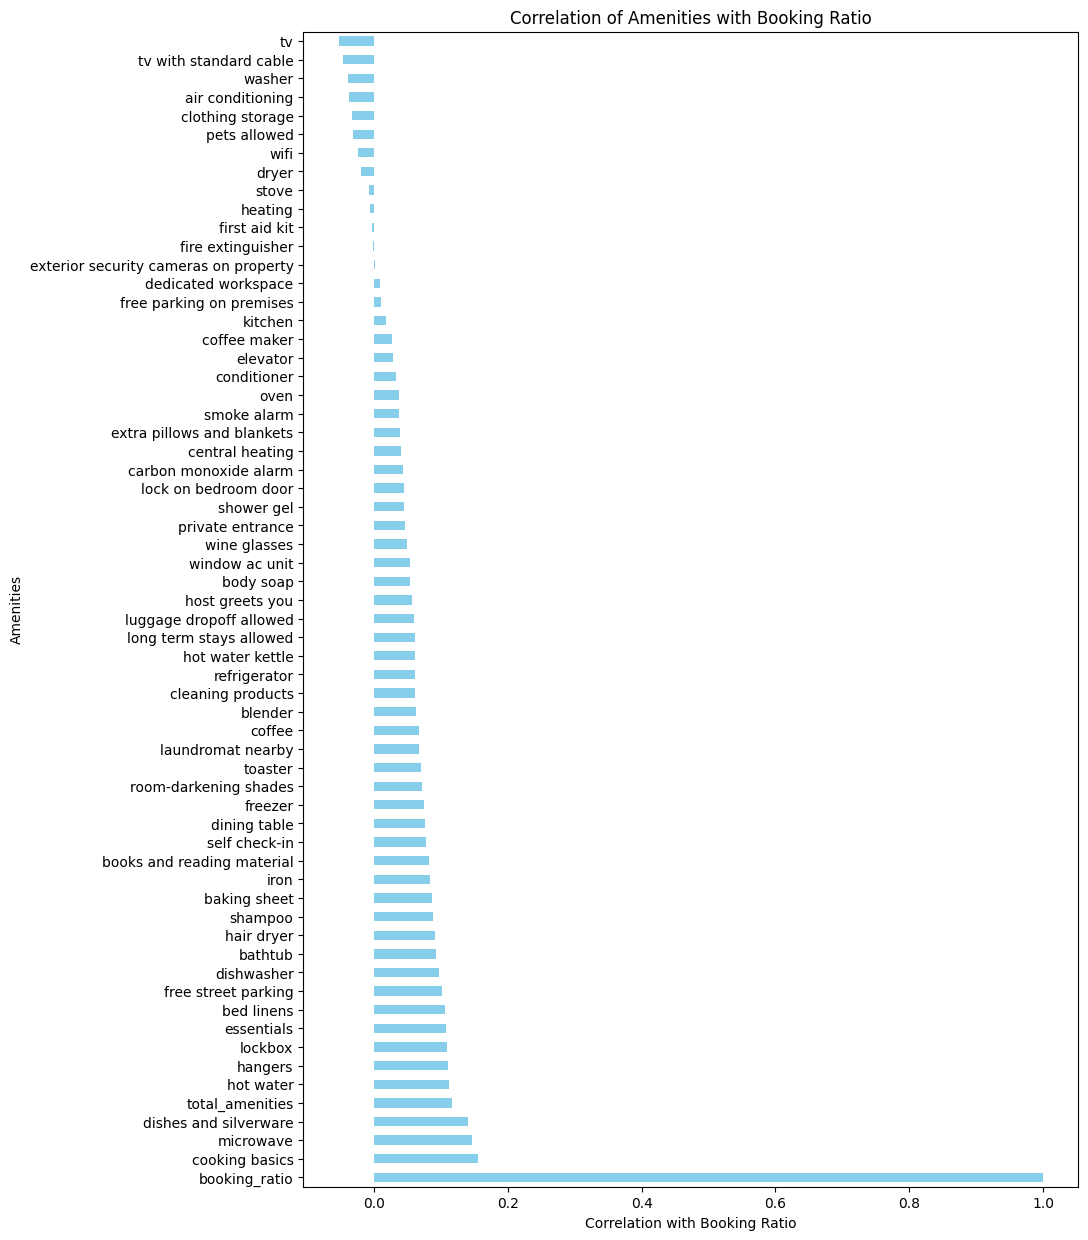

In [24]:

plt.figure(figsize=(10, 15))
correlation_with_booking_ratio.plot(kind='barh', color='skyblue')
plt.xlabel('Correlation with Booking Ratio')
plt.ylabel('Amenities')
plt.title('Correlation of Amenities with Booking Ratio')
plt.show()

In [27]:
model_data = merged_data = pd.merge(amenities, booking_ratio, left_on="id", right_on="listing_id")
model_data = model_data.drop(columns=["id","listing_id","amenities"])

model_data = model_data[model_data['booking_ratio'] <= 0.70]

X = model_data.drop(columns=["booking_ratio"])
y = model_data["booking_ratio"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

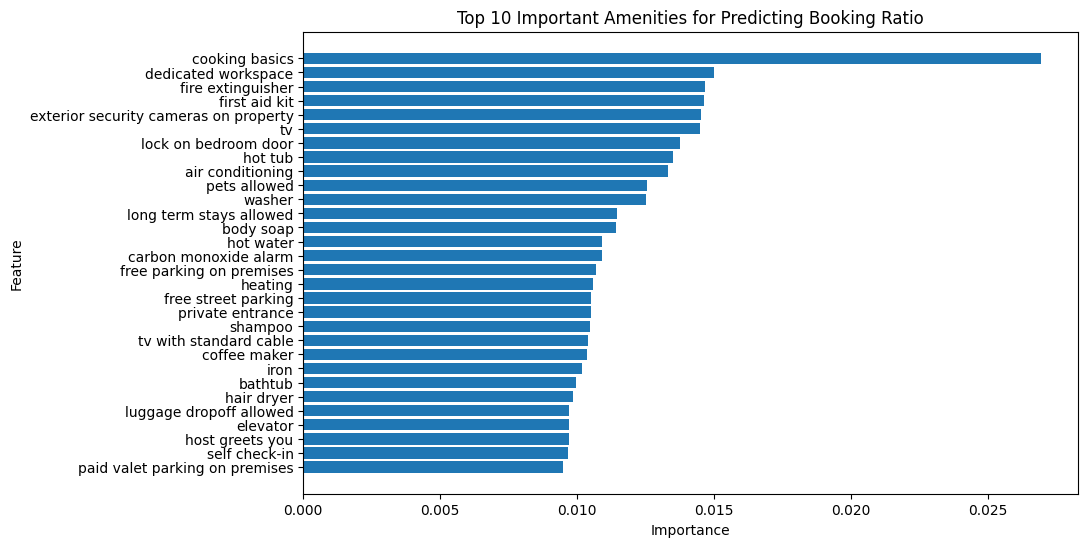

In [28]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df.head(30)['Feature'], feature_importance_df.head(30)['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Amenities for Predicting Booking Ratio')
plt.gca().invert_yaxis()
plt.show()